In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

In [7]:
path = "raw/train_wide.csv"

df = pd.read_csv(path)

df.head()

,user_id,sex,age,is_new_customer,seniority_months,income,segment,dep-7,card-2,dep-5,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
0,657788,F,42,0.0,114,132559.35,INDIVIDUALS,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,657795,M,44,0.0,114,81399.57,INDIVIDUALS,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,657790,M,42,0.0,114,NaN,INDIVIDUALS,0,0,0,...,0,0,0,0,0,1,0,0,1,1
3,657794,F,49,0.0,114,102189.00,VIP,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,657789,M,36,0.0,91,153725.49,VIP,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [8]:
df.describe()

,user_id,age,is_new_customer,seniority_months,income,dep-7,card-2,dep-5,card-1,card-5,...,dep-2,loan-2,card-4,loan-1,srv-3,loan-5,biz-4,dep-6,loan-4,card-3
count,3.761410e+05,376141.000000,376141.000000,376141.000000,2.910660e+05,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,...,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000,376141.000000
mean,8.203077e+05,42.536185,0.048189,83.439519,1.400772e+05,0.000144,0.738133,0.000726,0.181746,0.016648,...,0.037446,0.011642,0.018352,0.003472,0.105976,0.087316,0.054235,0.005769,0.122108,0.133769
std,4.711699e+05,16.209374,0.214166,2307.199623,2.454979e+05,0.011981,0.439651,0.026931,0.385635,0.127949,...,0.189852,0.107268,0.134221,0.058822,0.307808,0.282297,0.226481,0.075735,0.327411,0.340404
min,1.589300e+04,2.000000,0.000000,-999999.000000,3.731790e+03,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.906670e+05,29.000000,0.000000,23.000000,7.321765e+04,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8.682230e+05,42.000000,0.000000,62.000000,1.083771e+05,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.253743e+06,52.000000,0.000000,154.000000,1.643810e+05,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.553571e+06,117.000000,1.000000,256.000000,2.889440e+07,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 376141 entries, 0 to 376140
Data columns (total 29 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   user_id           376141 non-null  int64  
 1   sex               376138 non-null  str    
 2   age               376141 non-null  int64  
 3   is_new_customer   376141 non-null  float64
 4   seniority_months  376141 non-null  int64  
 5   income            291066 non-null  float64
 6   segment           374675 non-null  str    
 7   dep-7             376141 non-null  int64  
 8   card-2            376141 non-null  int64  
 9   dep-5             376141 non-null  int64  
 10  card-1            376141 non-null  int64  
 11  card-5            376141 non-null  int64  
 12  rko-2             376141 non-null  int64  
 13  rko-3             376141 non-null  int64  
 14  rko-4             376141 non-null  int64  
 15  dep-9             376141 non-null  int64  
 16  dep-1             376141 non-nu

In [10]:
df.isna().sum().sort_values()

user_id                 0
age                     0
is_new_customer         0
seniority_months        0
dep-7                   0
card-1                  0
dep-5                   0
card-2                  0
rko-2                   0
rko-3                   0
rko-4                   0
card-5                  0
dep-9                   0
rko-1                   0
dep-3                   0
dep-1                   0
loan-5                  0
biz-4                   0
dep-6                   0
dep-2                   0
loan-2                  0
card-4                  0
loan-1                  0
srv-3                   0
card-3                  0
loan-4                  0
sex                     3
segment              1466
income              85075
dtype: int64

In [51]:
num_cols = df.select_dtypes(include=['int64', 'float64'])

keep_cols = ['age', 'is_new_customer','seniority_months', 'income']

num_cols = num_cols[keep_cols]
num_cols

,age,is_new_customer,seniority_months,income
0,42,0.0,114,132559.35
1,44,0.0,114,81399.57
2,42,0.0,114,NaN
3,49,0.0,114,102189.00
4,36,0.0,91,153725.49
...,...,...,...,...
376136,23,0.0,33,57302.85
376137,23,0.0,33,NaN
376138,23,0.0,33,77784.78
376139,47,0.0,33,NaN


In [53]:
cat_cols = df.select_dtypes(include=['object', 'str'])
cat_cols

,sex,segment
0,F,INDIVIDUALS
1,M,INDIVIDUALS
2,M,INDIVIDUALS
3,F,VIP
4,M,VIP
...,...,...
376136,M,STUDENTS
376137,M,STUDENTS
376138,M,STUDENTS
376139,F,INDIVIDUALS


In [77]:
df['sex'] = df['sex'].fillna('UNKNOWN')

df['sex'].value_counts()

sex
M    215520
F    160618
Name: count, dtype: int64

In [75]:
df = df[df['sex'] != 'UNKNOWN']

df['sex'].value_counts()

sex
M    215520
F    160618
Name: count, dtype: int64

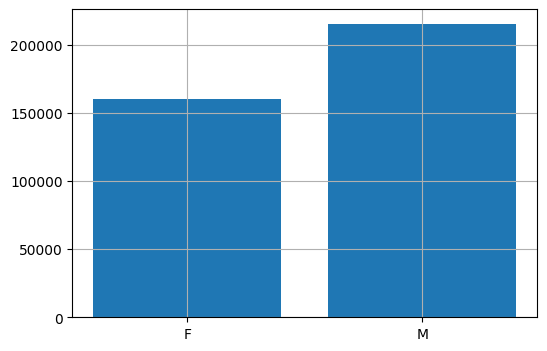

In [13]:
counts = df['sex'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.grid(True)
plt.show()

In [24]:
df['age'].value_counts()

age
21     13924
24     13116
22     12854
23     12689
45     11127
       ...  
111        3
116        3
114        2
109        2
117        1
Name: count, Length: 114, dtype: int64

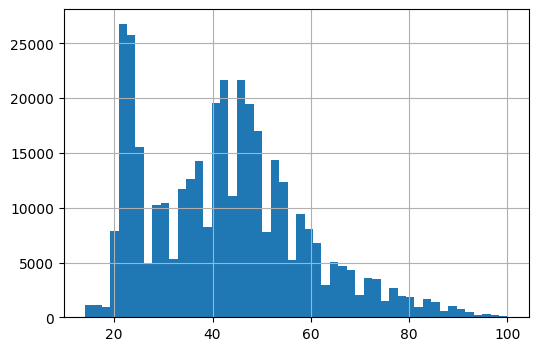

In [26]:
counts = df['age'].value_counts().sort_index()

age = df['age']
age = age[(age >= 14) & (age <= 100)]

plt.figure(figsize=(6, 4))
plt.hist(age, bins=50)
plt.grid(True)
plt.show()

In [25]:
df['seniority_months'].value_counts()

seniority_months
 10        9369
 8         7799
 7         6890
 22        6767
 20        6022
           ... 
 253         68
 255         43
 254         30
 256         20
-999999       2
Name: count, Length: 258, dtype: int64

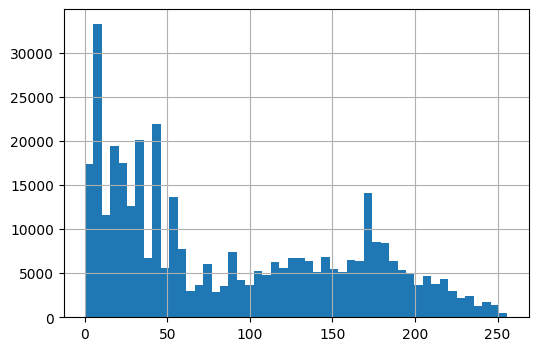

In [32]:
counts = df['seniority_months'].value_counts().sort_index()

seniority_months = df['seniority_months']
seniority_months = seniority_months[seniority_months >= 0]

plt.figure(figsize=(6, 4))
plt.hist(seniority_months, bins=50)
plt.grid(True)
plt.show()

In [36]:
df["income"].value_counts()

income
451931.22    178
181042.20     62
463625.16     51
128318.52     51
488798.49     42
            ... 
86137.50       1
55584.90       1
40134.90       1
161098.71      1
77784.78       1
Name: count, Length: 231436, dtype: int64

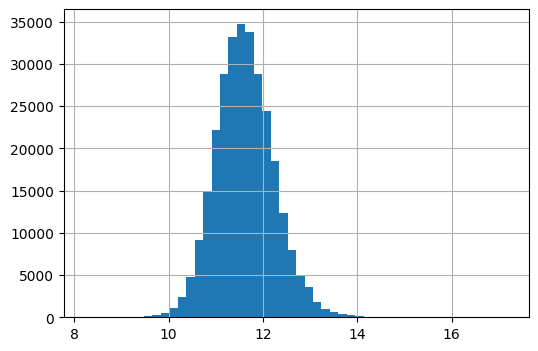

In [64]:
income = df['income']
income = income[income >= 0]

count = income.value_counts().sort_index()

log_income = np.log1p(income)

plt.figure(figsize=(6, 4))
plt.hist(log_income, bins=50)
plt.grid(True)
plt.show()

In [78]:
df['segment'] = df['segment'].fillna('UNKNOWN')

df['segment'].value_counts()

segment
INDIVIDUALS    246316
STUDENTS        94379
VIP             33977
UNKNOWN          1466
Name: count, dtype: int64

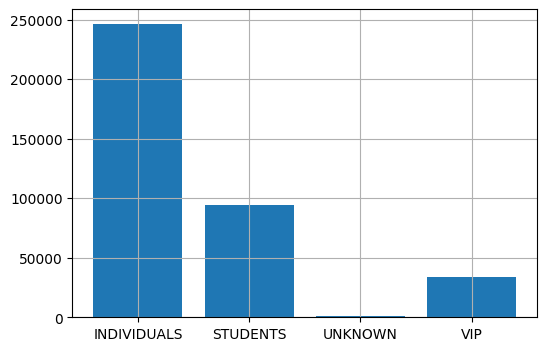

In [79]:
counts = df['segment'].value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(counts.index.astype(str), counts.values)
plt.grid(True)
plt.show()

<Axes: >

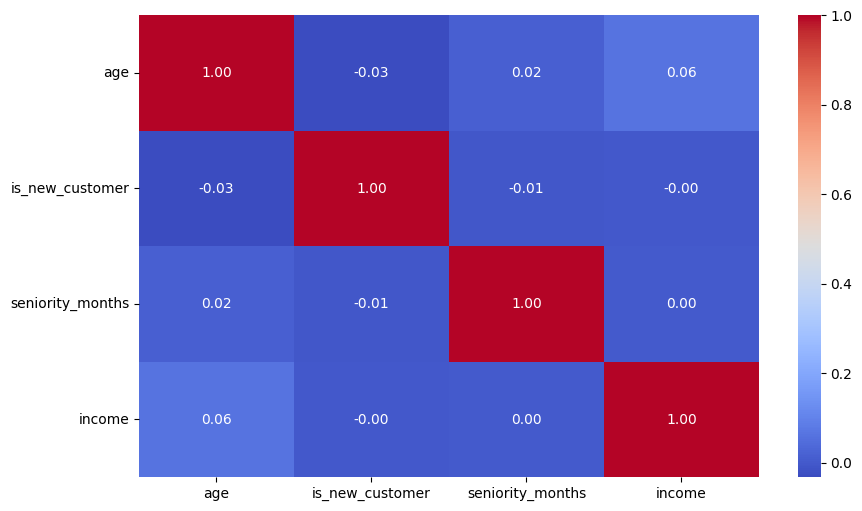

In [80]:
plt.figure(figsize=(10, 6))
sns.heatmap(num_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")

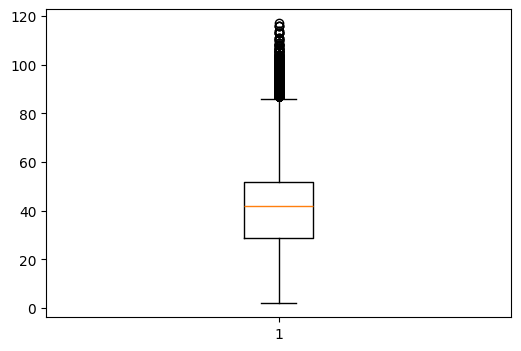

In [55]:
plt.figure(figsize=(6, 4))
plt.boxplot(df['age'])
plt.show()

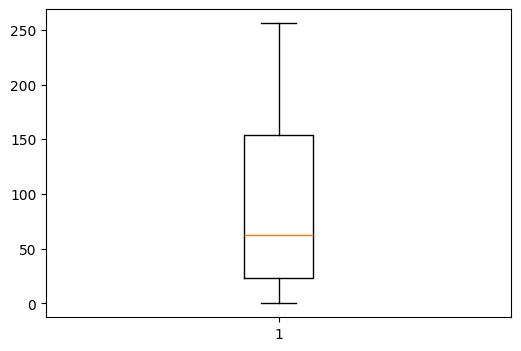

In [58]:
plt.figure(figsize=(6, 4))
plt.boxplot(seniority_months)
plt.show()

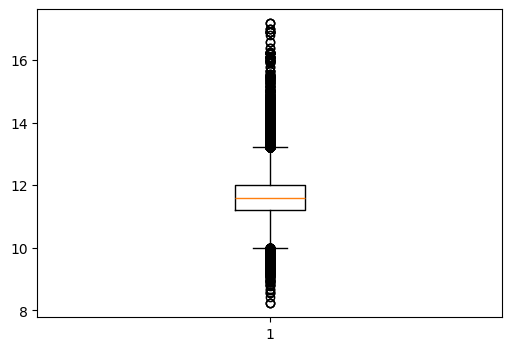

In [81]:
plt.figure(figsize=(6, 4))
plt.boxplot(log_income)
plt.show()

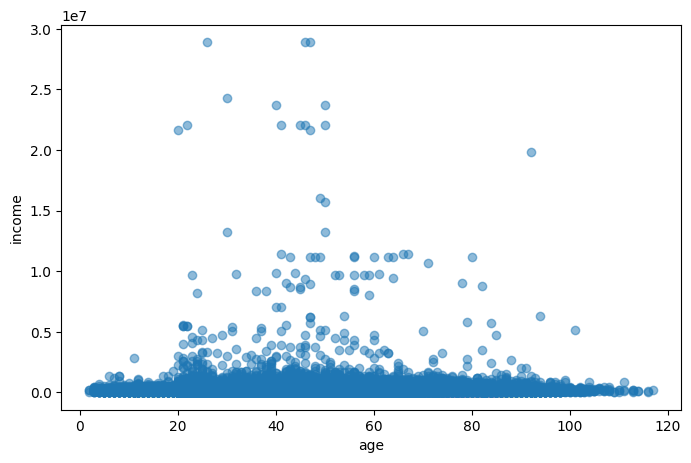

In [84]:
plt.figure(figsize=(8, 5))
plt.scatter(df['age'], df['income'], alpha=0.5)
plt.xlabel('age')
plt.ylabel('income')
plt.show()